# Week 3 — Demand Forecasting

**Goal:** Split each category's demand into a training period and a held-out test
period, then build a simple **moving-average baseline** forecast to beat later.

> The baseline is deliberately simple: it is the benchmark any real model (ARIMA)
> must outperform. `Clothing` is largely interpolated, so read its forecast with care.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DAILY_PATH = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'
TARGET = 'units_sold'
HORIZON = 30   # days held out for testing
WINDOW = 7     # moving-average window
SAMPLE_CAT = 'Electronics'

daily = pd.read_csv(DAILY_PATH, parse_dates=['date'])
daily = daily.sort_values(['product_category', 'date']).reset_index(drop=True)
print('Loaded shape:', daily.shape)
print('Date range:', daily['date'].min().date(), '->', daily['date'].max().date())
daily.head()

Loaded shape: (13057, 7)
Date range: 2020-01-01 -> 2023-04-01


,date,product_category,units_sold,inventory_level,unit_price,warehouse_dispatch_rate,promotion_flag
0,2020-01-01,Apparel,453.9,719.0,168.09,426.4,False
1,2020-01-02,Apparel,445.1,716.9,171.46,69.9,False
2,2020-01-03,Apparel,483.4,711.2,167.15,463.2,False
3,2020-01-04,Apparel,600.6,712.1,172.11,557.1,True
4,2020-01-05,Apparel,407.2,1216.3,171.24,422.8,False


## 1. Train / test split

For every category, hold out the **last 30 days** as the test set and train on
everything before it. Keeping the split per category means each product is
evaluated on its own recent history.

In [2]:
def train_test_split(frame, horizon=HORIZON):
    """Split each category into train (all but last `horizon` days) and test (last `horizon`)."""
    train_parts, test_parts = [], []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.sort_values('date')
        train_parts.append(sub.iloc[:-horizon])
        test_parts.append(sub.iloc[-horizon:])
    train = pd.concat(train_parts, ignore_index=True)
    test = pd.concat(test_parts, ignore_index=True)
    return train, test

train, test = train_test_split(daily)
print('Train rows:', len(train), '| Test rows:', len(test))
print('Test days per category:', test.groupby('product_category').size().unique())
print('Train ends:', train['date'].max().date(), '| Test:', test['date'].min().date(), '->', test['date'].max().date())

Train rows: 12727 | Test rows: 330
Test days per category: [30]
Train ends: 2023-03-02 | Test: 2023-03-03 -> 2023-04-01


## 2. Moving-average baseline

The baseline forecast for the whole test window is the **average of the last 7
training days** for each category, held flat across all 30 forecast days. Simple,
but a fair benchmark.

In [3]:
def moving_average_forecast(train_frame, test_frame, window=WINDOW):
    """Forecast each test day as the mean of the last `window` training days (flat per category)."""
    parts = []
    for cat, sub in test_frame.groupby('product_category'):
        sub = sub.sort_values('date').copy()
        last_window = (train_frame[train_frame['product_category'] == cat]
                       .sort_values('date')[TARGET].tail(window))
        sub['forecast_ma'] = last_window.mean()
        parts.append(sub[['date', 'product_category', TARGET, 'forecast_ma']])
    return pd.concat(parts, ignore_index=True)

baseline = moving_average_forecast(train, test)
baseline['forecast_ma'] = baseline['forecast_ma'].round(2)
print('Baseline forecast rows:', len(baseline))
baseline.head()

Baseline forecast rows: 330


,date,product_category,units_sold,forecast_ma
0,2023-03-03,Apparel,543.9,543.9
1,2023-03-04,Apparel,543.9,543.9
2,2023-03-05,Apparel,543.9,543.9
3,2023-03-06,Apparel,543.9,543.9
4,2023-03-07,Apparel,543.9,543.9


## 3. Visualize baseline vs actual

Plot the recent training history, the actual test values, and the flat baseline
forecast for one category so we can eyeball how the benchmark behaves.

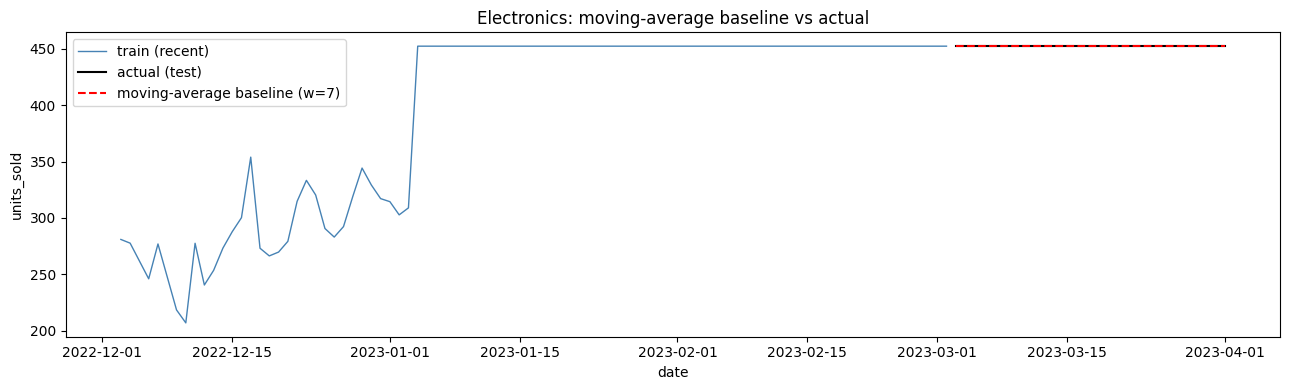

In [4]:
hist = train[train['product_category'] == SAMPLE_CAT].sort_values('date').tail(90)
act = baseline[baseline['product_category'] == SAMPLE_CAT].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist['date'], hist[TARGET], color='steelblue', lw=1, label='train (recent)')
ax.plot(act['date'], act[TARGET], color='black', lw=1.5, label='actual (test)')
ax.plot(act['date'], act['forecast_ma'], color='red', lw=1.5, ls='--',
        label=f'moving-average baseline (w={WINDOW})')
ax.set_title(f'{SAMPLE_CAT}: moving-average baseline vs actual')
ax.set_xlabel('date'); ax.set_ylabel(TARGET); ax.legend()
plt.tight_layout(); plt.show()